In [79]:
from PyAstronomy.pyasl import foldAt
import matplotlib.pylab as plt
import numpy as np

from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt 

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk


In [80]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[3].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()


x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

# Generate some data ...
time = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
flux1 = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
t0 = 2454966.3304
t0_in_bkjd = t0 - 2454833

phases1 = foldAt(time,4.865, T0=t0_in_bkjd-0.2)

# Sort with respect to phase
# First, get the order of indices ...
sortIndi = np.argsort(phases1)
# ... and, second, rearrange the arrays.
phases1 = phases1[sortIndi]
flux1 = flux1[sortIndi]

phases_med =[]
x_med = [i/100 for i in range(100)]
for fase in x_med:
	aux = 0
	aux_2 = 0
	for i in range(len(phases1)): 
		if phases1[i]>fase and phases1[i]<fase+0.01:
			aux += flux1[i]
			aux_2 += 1
	phases_med.append(aux/aux_2)

plt.plot(phases1, flux1, 'k')
plt.plot(x_med, phases_med, 'r-', label = 'median value')
print(np.min(x_med))

0.0


In [81]:
#dados parâmetros###
dados_1=np.loadtxt('setor1_graf12.txt')

temp_med = dados_1[:,0]
ener_setor1 = dados_1[:,1]
print(temp_med)

[1326.7227  1327.231   1327.9585  1328.155   1328.58575 1329.3913
 1329.4382  1330.141   1331.8349  1333.0273  1333.9356  1334.1334
 1335.1761  1335.3849  1335.71265 1336.9675  1337.0473  1338.2573
 1338.45155 1339.8495  1340.5272  1344.82425 1345.4024  1345.43635
 1345.56665 1346.04575 1346.2109  1346.28245 1346.5317  1349.83965
 1350.1134  1350.315   1352.3578 ]


In [82]:
#dados parâmetros###
dados_1=np.loadtxt('setor1_graf12.txt')

temp_med = dados_1[:,0]
ener_setor1 = dados_1[:,1]
enerlog10 = np.log10(ener_setor1)

t0 = 2454966.3304
t0_in_bkjd = t0 - 2454833

fase1 = foldAt(temp_med,4.865, T0=t0_in_bkjd-0.2)
plt.plot(fase1, enerlog10, 'ko')


<IPython.core.display.Javascript object>


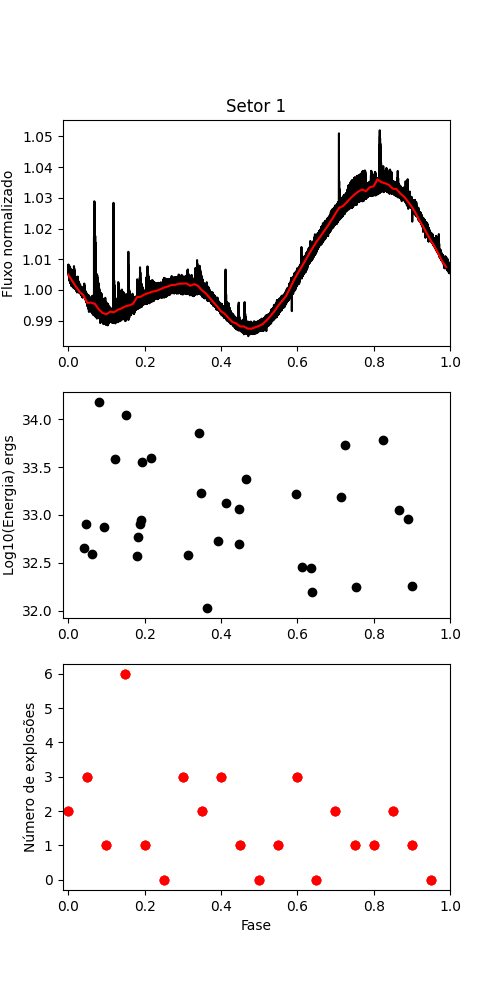

In [83]:
fig,(ax1,ax2,ax3) = plt.subplots(3,1,figsize=(5,10))

ax1.set_title('Setor 1')
ax1.plot(phases1, flux1, 'k',x_med, phases_med, 'r-', label = 'median value')
ax1.set_ylabel('Fluxo normalizado')
ax2.plot(fase1, enerlog10, 'ko')
ax2.set_ylabel('Log10(Energia) ergs')
ax3.plot(x_med0, phases_med0, 'ro')
#ax3.set_ylabel('Relative flux [ppt]')
ax1.set_xlim(-0.015,1.00005)
ax2.set_xlim(-0.015,1.00005)
ax3.set_xlim(-0.015,1.00005)

ax3.set_xlabel('Fase')
ax3.set_ylabel('Número de explosões')
plt.show()


In [85]:
fase2 = foldAt(temp_med,4.865, T0=t0_in_bkjd-0.2)
# Sort with respect to phase
# First, get the order of indices ...
sortIndi = np.argsort(fase2)
# ... and, second, rearrange the arrays.
fase2 = fase2[sortIndi]
flux1 = flux1[sortIndi]

phases_med0 =[]
x_med0 = [i/20 for i in range(20)]
for fase in x_med0:
	aux = 0
	aux_2 = 0
	for i in range(len(fase2)): 
		if fase2[i]>fase and fase2[i]<fase+0.05:
			aux += flux1[i]
			aux_2 += 1
	phases_med0.append(aux_2)

plt.plot(x_med0, phases_med0, 'ro')
plt.show()

In [75]:
print( np.min(phases1),np.min(fase1),np.min(x_med0))

8.947309774498535e-05 0.04092497433489939 0.0
